In [10]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

main_path   = Path("data/pulmonary-chest-xray-abnormalities")
shmask_path = Path("data/shcxr-lung-mask")

print("Main bundle exists :", main_path.exists())
print("Shenzhen masks exist:", shmask_path.exists())

Main bundle exists : True
Shenzhen masks exist: True


In [7]:
import os

for base in [main_path, shmask_path]:
    print("=" * 60)
    print(base)
    for root, dirs, files in os.walk(base):
        depth = root.replace(str(base), "").count(os.sep)
        if depth <= 2:
            print("   " * depth, os.path.basename(root), f"({len(files)} files)")

data/pulmonary-chest-xray-abnormalities
 pulmonary-chest-xray-abnormalities (1 files)
    Montgomery (0 files)
       __MACOSX (0 files)
       MontgomerySet (2 files)
    ChinaSet_AllFiles (1 files)
       ChinaSet_AllFiles (1 files)
data/shcxr-lung-mask
 shcxr-lung-mask (566 files)
    mask (566 files)


In [9]:
from pathlib import Path
main_path   = Path(main_path)
shmask_path = Path(shmask_path)

MONT_IMG   = main_path / "Montgomery" / "MontgomerySet" / "CXR_png"
MONT_LEFT  = main_path / "Montgomery" / "MontgomerySet" / "ManualMask" / "leftMask"
MONT_RIGHT = main_path / "Montgomery" / "MontgomerySet" / "ManualMask" / "rightMask"
SHEN_IMG   = main_path / "ChinaSet_AllFiles" / "ChinaSet_AllFiles" / "CXR_png"
SHEN_MASK  = shmask_path / "mask"

for name, p in [("Montgomery images", MONT_IMG),
                ("Montgomery left masks", MONT_LEFT),
                ("Montgomery right masks", MONT_RIGHT),
                ("Shenzhen images", SHEN_IMG),
                ("Shenzhen masks", SHEN_MASK)]:
    print("OK " if p.exists() else "MISSING", name, "->", p)

OK  Montgomery images -> data/pulmonary-chest-xray-abnormalities/Montgomery/MontgomerySet/CXR_png
OK  Montgomery left masks -> data/pulmonary-chest-xray-abnormalities/Montgomery/MontgomerySet/ManualMask/leftMask
OK  Montgomery right masks -> data/pulmonary-chest-xray-abnormalities/Montgomery/MontgomerySet/ManualMask/rightMask
OK  Shenzhen images -> data/pulmonary-chest-xray-abnormalities/ChinaSet_AllFiles/ChinaSet_AllFiles/CXR_png
OK  Shenzhen masks -> data/shcxr-lung-mask/mask


In [13]:
def find_shenzhen_mask(stem, mask_dir):
    for cand in (mask_dir / f"{stem}.png", mask_dir / f"{stem}_mask.png"):
        if cand.exists():
            return cand
    return None

records = []
for img_path in sorted(MONT_IMG.glob("*.png")):
    left = MONT_LEFT  / img_path.name
    right = MONT_RIGHT / img_path.name
    records.append({
        "dataset": "Montgomery",
        "image": img_path,
        "mask_left":  left  if left.exists()  else None,
        "mask_right": right if right.exists() else None,
        "mask": None,
        "has_mask": left.exists() and right.exists(),
    })

for img_path in sorted(SHEN_IMG.glob("*.png")):
    m = find_shenzhen_mask(img_path.stem, SHEN_MASK)
    records.append({
        "dataset": "Shenzhen",
        "image": img_path,
        "mask_left": None, "mask_right": None,
        "mask": m,
        "has_mask": m is not None,
    })
    
print("Total X-rays:", len(records))

Total X-rays: 800


In [14]:
print("By dataset:", dict(Counter(r["dataset"] for r in records)))
n_with = sum(r["has_mask"] for r in records)
print("With mask   :", n_with)
print("Without mask:", len(records) - n_with)

By dataset: {'Montgomery': 138, 'Shenzhen': 662}
With mask   : 704
Without mask: 96


In [15]:
def load_image(path):
    return np.array(Image.open(path).convert("L"))

def load_mask(record):
    if not record["has_mask"]:
        return None
    
    if record["dataset"] == "Montgomery":
        left  = np.array(Image.open(record["mask_left"]).convert("L"))
        right = np.array(Image.open(record["mask_right"]).convert("L"))
        both  = (left > 127) | (right > 127)
        return both.astype(np.uint8) * 255
    
    else:
        m = np.array(Image.open(record["mask"]).convert("L"))
        return (m > 127).astype(np.uint8) * 255
    
example = next(r for r in records if r["has_mask"])
img = load_image(example["image"])
msk = load_mask(example)
print(example["dataset"], example["image"].name)
print("image size:", img.shape, "| mask values:", np.unique(msk))

Montgomery MCUCXR_0001_0.png
image size: (4020, 4892) | mask values: [  0 255]


In [18]:
def overlay(image, mask, alpha=0.4):
    rgb = np.stack([image, image, image], axis=-1).astype(float)
    if mask is None:
        return rgb.astype(np.uint8)
    if mask.shape != image.shape:
        mask = np.array(Image.fromarray(mask).resize(
            (image.shape[1], image.shape[0]), Image.NEAREST
        ))
    
    is_lung = mask > 127
    red = np.array([255, 0, 0], dtype=float)
    rgb[is_lung] = (1 - alpha) * rgb[is_lung] + alpha * red
    return np.clip(rgb, 0, 255).astype(np.uint8)

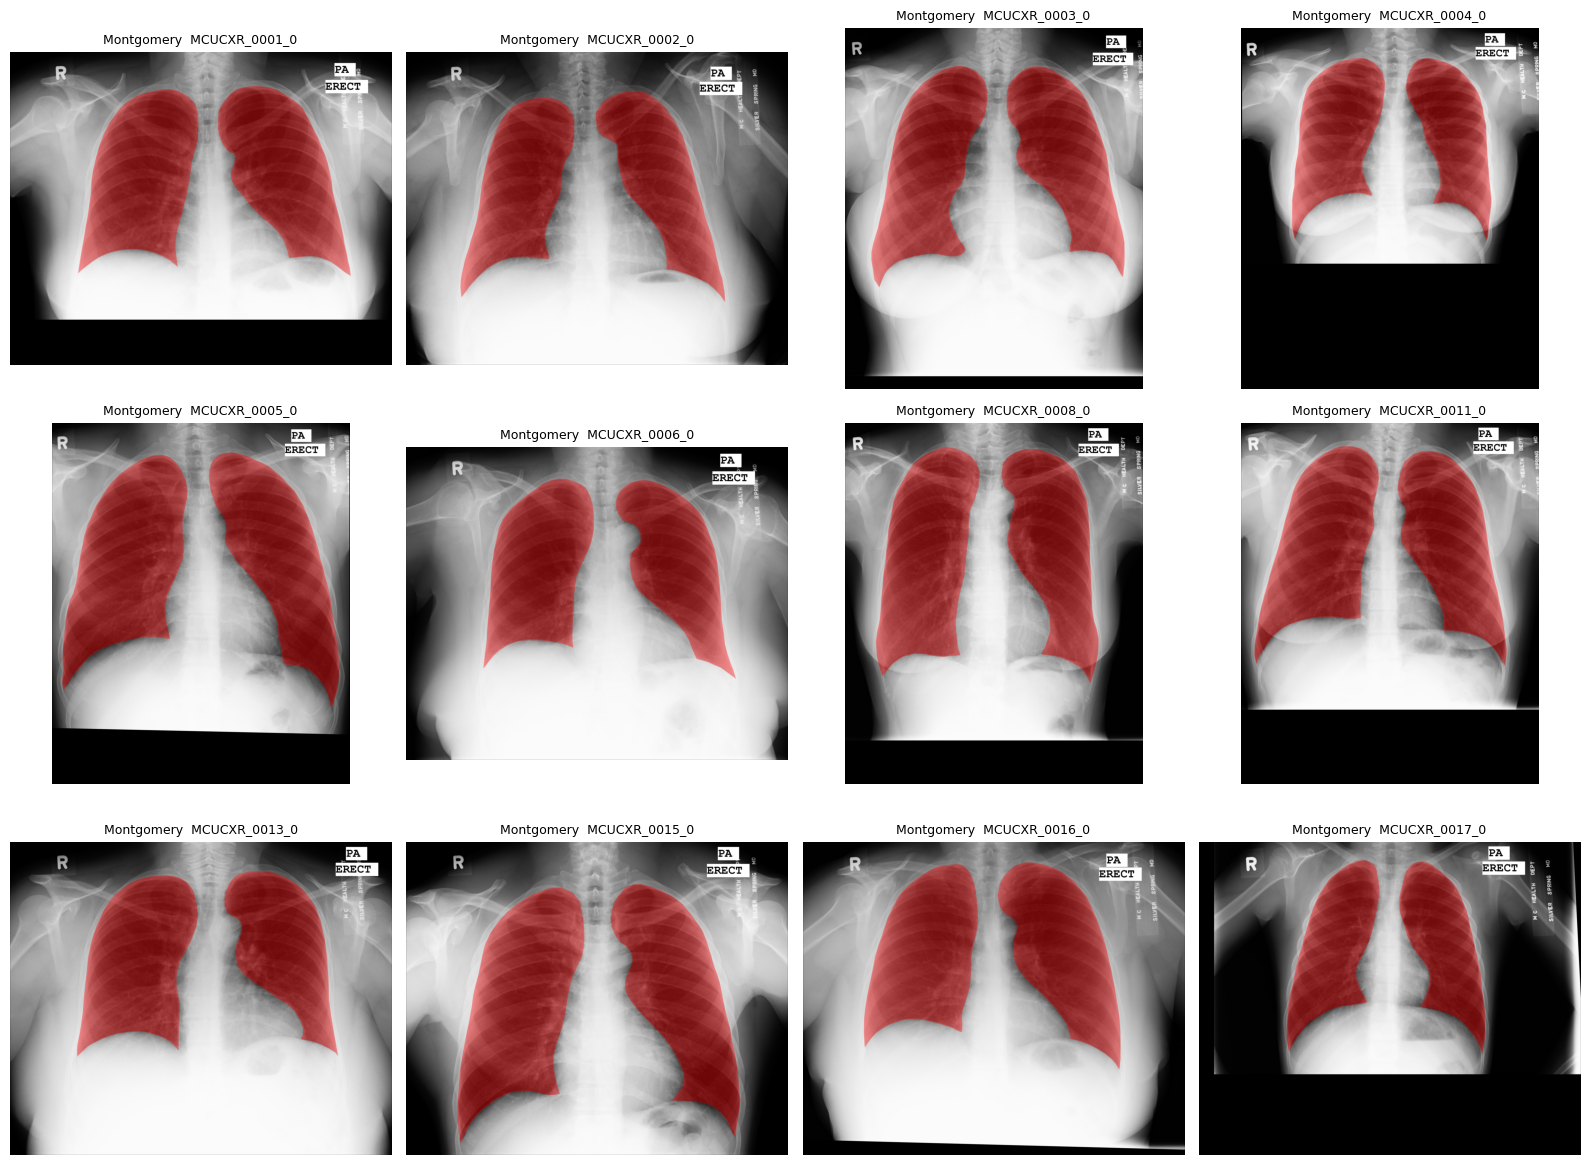

In [19]:
pairs = [r for r in records if r["has_mask"]][:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, r in zip(axes.flat, pairs):
    img = load_image(r["image"])
    msk = load_mask(r)
    ax.imshow(overlay(img, msk))
    ax.set_title(f'{r["dataset"]}  {r["image"].stem}', fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [20]:
sizes = Counter()
for r in records:
    h, w = load_image(r["image"]).shape
    sizes[(h, w)] += 1

print("Number of different sizes:", len(sizes))
print("Most common sizes:")
for (h, w), count in sizes.most_common(8):
    print(f"   {h} x {w}  ->  {count} images")

Number of different sizes: 527
Most common sizes:
   4892 x 4020  ->  97 images
   4020 x 4892  ->  41 images
   2939 x 3000  ->  15 images
   2945 x 3000  ->  15 images
   2947 x 3000  ->  12 images
   2951 x 3000  ->  11 images
   2937 x 3000  ->  11 images
   2943 x 3000  ->  11 images


In [23]:
import csv

missing = [r for r in records if not r["has_mask"]]
print("Images with NO mask:", len(missing))
print("By dataset:", dict(Counter(r["dataset"] for r in missing)))
for r in missing[:15]:
    print("  ", r["dataset"], r["image"].name)

with open("dataset_manifest.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["dataset", "image_path", "has_mask"])
    for r in records:
        writer.writerow([r["dataset"], str(r["image"]), int(r["has_mask"])])
print("Saved dataset_manifest.csv")

Images with NO mask: 96
By dataset: {'Shenzhen': 96}
   Shenzhen CHNCXR_0025_0.png
   Shenzhen CHNCXR_0036_0.png
   Shenzhen CHNCXR_0037_0.png
   Shenzhen CHNCXR_0038_0.png
   Shenzhen CHNCXR_0039_0.png
   Shenzhen CHNCXR_0040_0.png
   Shenzhen CHNCXR_0065_0.png
   Shenzhen CHNCXR_0181_0.png
   Shenzhen CHNCXR_0182_0.png
   Shenzhen CHNCXR_0183_0.png
   Shenzhen CHNCXR_0184_0.png
   Shenzhen CHNCXR_0185_0.png
   Shenzhen CHNCXR_0186_0.png
   Shenzhen CHNCXR_0187_0.png
   Shenzhen CHNCXR_0188_0.png
Saved dataset_manifest.csv
